# Time Series in Environmental Data Analysis

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
data_url = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_daily_mlo.csv'
dat = pd.read_csv(data_url, comment='#', header=None)
# dat = pd.read_csv('data/co2_daily_mlo.csv', comment='#', header=None)  # if working offline, use local file
dat.columns = ['year', 'month', 'day', 'decimal_date', 'pCO2']

In [29]:
last_two_years = dat[dat['year'] >= (dat['year'].max() - 2)]

Text(0.5, 0, 'Year')

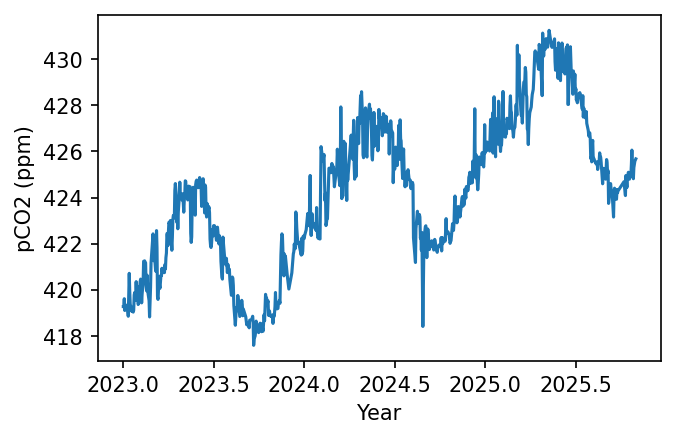

In [34]:
fig, ax = plt.subplots()
ax.plot(last_two_years['decimal_date'], last_two_years['pCO2'])
ax.set_ylabel('pCO2 (ppm)')
ax.set_xlabel('Year')

In [37]:
from statsmodels.formula.api import ols, glm

                            OLS Regression Results                            
Dep. Variable:                   pCO2   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     824.3
Date:                Mon, 03 Nov 2025   Prob (F-statistic):          6.73e-126
Time:                        13:58:07   Log-Likelihood:                -1841.7
No. Observations:                 819   AIC:                             3687.
Df Residuals:                     817   BIC:                             3697.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -5196.9583    195.783    -26.544   

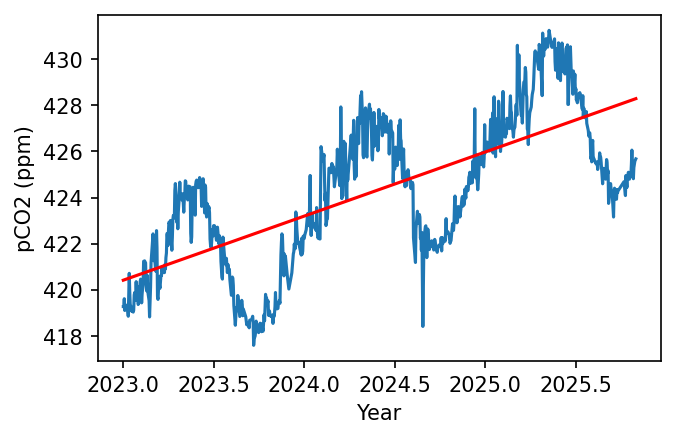

In [43]:
naive_model = ols('pCO2 ~ decimal_date', data=last_two_years).fit()
print(naive_model.summary())

fig, ax = plt.subplots()
ax.plot(last_two_years['decimal_date'], last_two_years['pCO2'])
ax.set_ylabel('pCO2 (ppm)')
ax.set_xlabel('Year')
ax.plot(last_two_years['decimal_date'], naive_model.fittedvalues, color='red')

                            OLS Regression Results                            
Dep. Variable:                   pCO2   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     2416.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        13:59:40   Log-Likelihood:                -1188.8
No. Observations:                 819   AIC:                             2386.
Df Residuals:                     815   BIC:                             2405.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -6067.5940     91.324    -66.440   

/tmp/ipykernel_1645951/1703526294.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_two_years['sin_annual'] = np.sin(2 * np.pi * last_two_years['decimal_date'])
/tmp/ipykernel_1645951/1703526294.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_two_years['cos_annual'] = np.cos(2 * np.pi * last_two_years['decimal_date'])


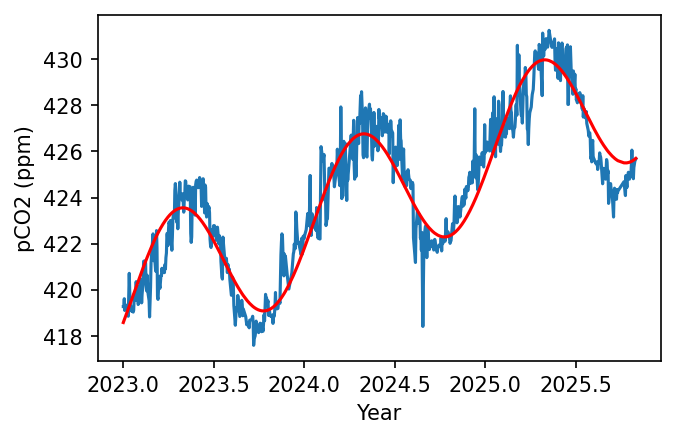

In [47]:
last_two_years['sin_annual'] = np.sin(2 * np.pi * last_two_years['decimal_date'])
last_two_years['cos_annual'] = np.cos(2 * np.pi * last_two_years['decimal_date'])

harmonic_model_formula = 'pCO2 ~ decimal_date + sin_annual + cos_annual'
harmonic_model = ols(harmonic_model_formula, data=last_two_years).fit()
print(harmonic_model.summary())

fig, ax = plt.subplots()
ax.plot(last_two_years['decimal_date'], last_two_years['pCO2'])
ax.set_ylabel('pCO2 (ppm)')
ax.set_xlabel('Year')
ax.plot(last_two_years['decimal_date'], harmonic_model.fittedvalues, color='red')

array([418.58834061, 418.64518162, 418.70440646, 418.76177042,
       418.8215075 , 418.87933624, 418.9373717 , 418.99775976,
       419.05617228, 419.11692062, 419.1756508 , 419.23451505,
       419.29568563, 419.35477828, 419.41615452, 419.47541533,
       419.5347366 , 419.59630322, 419.65570251, 419.71731864,
       419.77673538, 419.83613849, 419.89771172, 419.95704193,
       420.01850815, 420.07770494, 420.13681413, 420.1980045 ,
       420.25689038, 420.31781803, 420.37642062, 420.43486228,
       420.49528317, 420.55335277, 420.61335716, 420.6709957 ,
       420.72840119, 420.78767165, 420.84455909, 420.90117109,
       420.95957415, 421.01558248, 421.0733301 , 421.12867822,
       421.18368179, 421.24034432, 421.29460486, 421.3504685 ,
       421.40393156, 421.5115524 , 421.61735992, 421.66860613,
       421.77151536, 421.82128268, 422.01863348, 422.06568865,
       422.11388575, 422.1597709 , 422.20506534, 422.25140213,
       422.29546081, 422.34049396, 422.38327461, 422.42

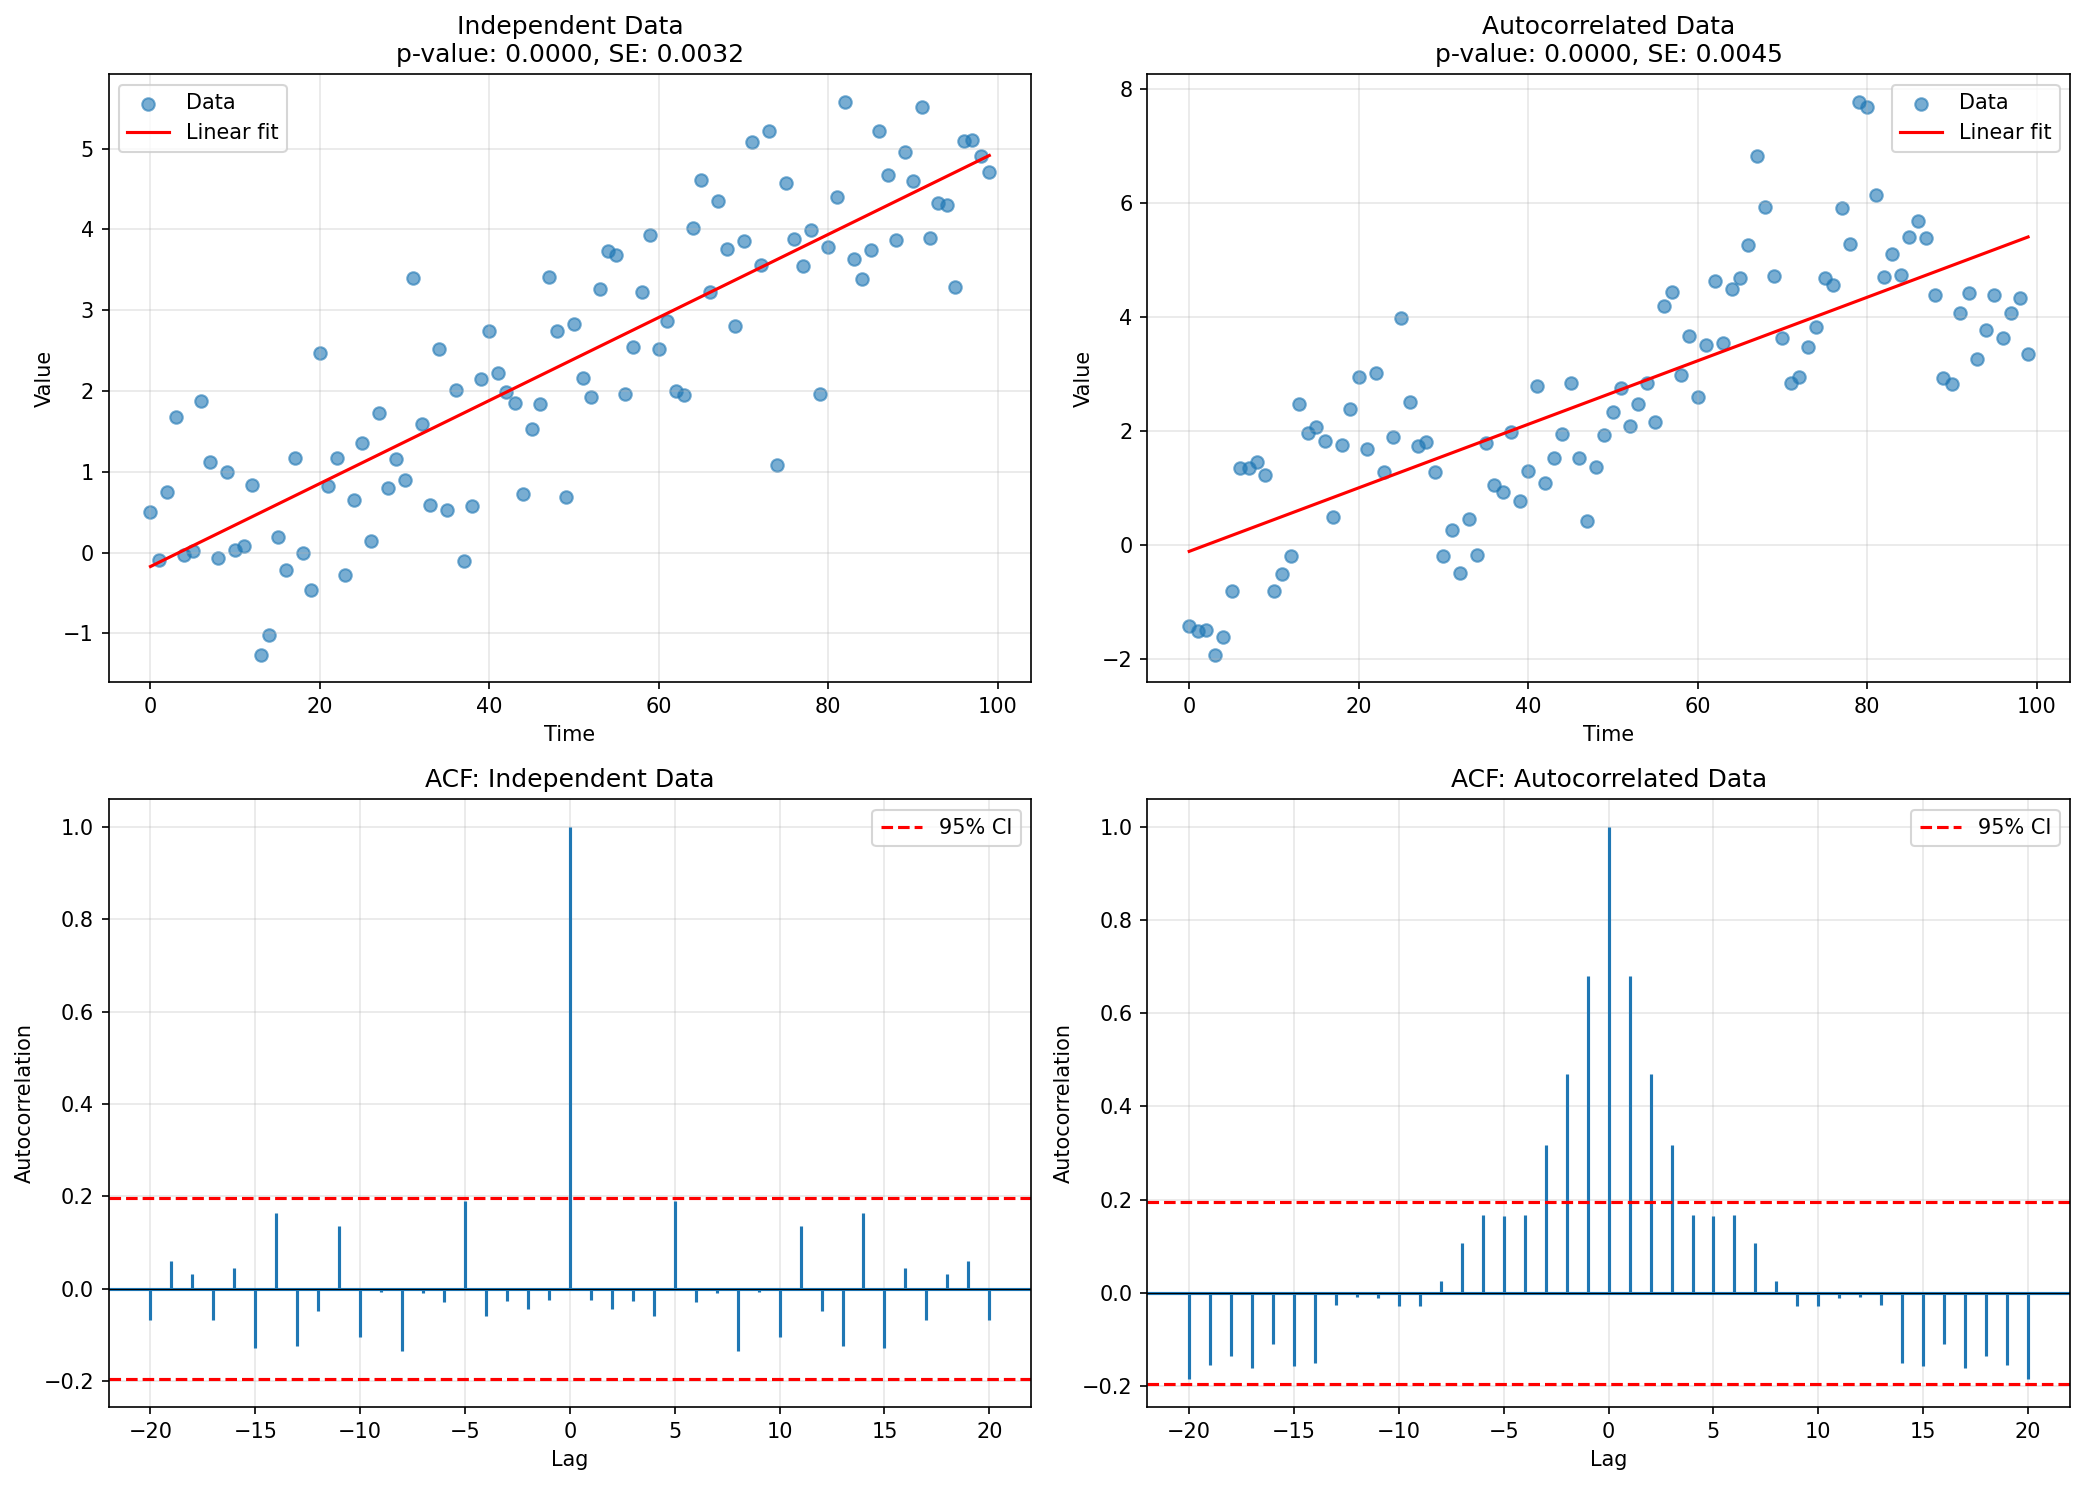


COMPARISON: Impact of Autocorrelation

Independent Data:
  Actual sample size: 100
  Effective sample size: ≈ 200.8
  Standard error: 0.0032
  p-value: 0.0000
  Sum of ACF (lags 1-20): -0.251

Autocorrelated Data:
  Actual sample size: 100
  Effective sample size: ≈ 41.5
  Standard error (naive): 0.0045
  Standard error (corrected): ≈ 0.0070
  p-value (naive): 0.0000
  Sum of ACF (lags 1-20): 0.706

⚠️  The naive analysis underestimates uncertainty by 58.5%!


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Generate two time series with different autocorrelation structures
n = 100
time = np.arange(n)

# Independent observations (white noise)
independent_data = np.random.normal(0, 1, n)

# Autocorrelated observations (AR(1) process)
autocorrelated_data = np.zeros(n)
autocorrelated_data[0] = np.random.normal(0, 1)
phi = 0.8  # autocorrelation coefficient
for t in range(1, n):
    autocorrelated_data[t] = phi * autocorrelated_data[t-1] + np.random.normal(0, 1)

# Add a trend to both
trend = 0.05 * time
independent_series = independent_data + trend
autocorrelated_series = autocorrelated_data + trend

# Perform naive linear regression (ignoring autocorrelation)
slope_ind, intercept_ind, r_ind, p_ind, se_ind = stats.linregress(time, independent_series)
slope_auto, intercept_auto, r_auto, p_auto, se_auto = stats.linregress(time, autocorrelated_series)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Independent data
axes[0, 0].scatter(time, independent_series, alpha=0.6, label='Data')
axes[0, 0].plot(time, intercept_ind + slope_ind * time, 'r-', label='Linear fit')
axes[0, 0].set_title(f'Independent Data\np-value: {p_ind:.4f}, SE: {se_ind:.4f}')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Value')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Autocorrelated data
axes[0, 1].scatter(time, autocorrelated_series, alpha=0.6, label='Data')
axes[0, 1].plot(time, intercept_auto + slope_auto * time, 'r-', label='Linear fit')
axes[0, 1].set_title(f'Autocorrelated Data\np-value: {p_auto:.4f}, SE: {se_auto:.4f}')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Value')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: ACF for independent data
from pandas.plotting import autocorrelation_plot
axes[1, 0].acorr(independent_series - (intercept_ind + slope_ind * time), maxlags=20, usevlines=True)
axes[1, 0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 0].axhline(y=1.96/np.sqrt(n), color='r', linestyle='--', label='95% CI')
axes[1, 0].axhline(y=-1.96/np.sqrt(n), color='r', linestyle='--')
axes[1, 0].set_title('ACF: Independent Data')
axes[1, 0].set_xlabel('Lag')
axes[1, 0].set_ylabel('Autocorrelation')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: ACF for autocorrelated data
axes[1, 1].acorr(autocorrelated_series - (intercept_auto + slope_auto * time), maxlags=20, usevlines=True)
axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].axhline(y=1.96/np.sqrt(n), color='r', linestyle='--', label='95% CI')
axes[1, 1].axhline(y=-1.96/np.sqrt(n), color='r', linestyle='--')
axes[1, 1].set_title('ACF: Autocorrelated Data')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('Autocorrelation')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate effective sample size for autocorrelated data
# IMPORTANT: Calculate ACF on residuals (detrended data) to get true autocorrelation structure
residuals_ind = independent_series - (intercept_ind + slope_ind * time)
residuals_auto = autocorrelated_series - (intercept_auto + slope_auto * time)

# Calculate ACF for autocorrelated residuals
acf_values_auto = [np.corrcoef(residuals_auto[:-i], residuals_auto[i:])[0, 1] 
                   for i in range(1, 21)]
n_effective_auto = n / (1 + 2 * np.sum(acf_values_auto))

# Calculate ACF for independent residuals (for comparison)
acf_values_ind = [np.corrcoef(residuals_ind[:-i], residuals_ind[i:])[0, 1] 
                  for i in range(1, 21)]
n_effective_ind = n / (1 + 2 * np.sum(acf_values_ind))

print("\n" + "="*60)
print("COMPARISON: Impact of Autocorrelation")
print("="*60)
print(f"\nIndependent Data:")
print(f"  Actual sample size: {n}")
print(f"  Effective sample size: ≈ {n_effective_ind:.1f}")
print(f"  Standard error: {se_ind:.4f}")
print(f"  p-value: {p_ind:.4f}")
print(f"  Sum of ACF (lags 1-20): {np.sum(acf_values_ind):.3f}")

print(f"\nAutocorrelated Data:")
print(f"  Actual sample size: {n}")
print(f"  Effective sample size: ≈ {n_effective_auto:.1f}")
print(f"  Standard error (naive): {se_auto:.4f}")
print(f"  Standard error (corrected): ≈ {se_auto * np.sqrt(n/n_effective_auto):.4f}")
print(f"  p-value (naive): {p_auto:.4f}")
print(f"  Sum of ACF (lags 1-20): {np.sum(acf_values_auto):.3f}")
print(f"\n⚠️  The naive analysis underestimates uncertainty by {(1-n_effective_auto/n)*100:.1f}%!")

In [19]:
np.sum([np.corrcoef(autocorrelated_series[:-i], autocorrelated_series[i:])[0, 1] 
              for i in range(1, 21)])

np.float64(11.882307145000583)

In [20]:
np.sum([np.corrcoef(independent_series[:-i], independent_series[i:])[0, 1] 
              for i in range(1, 21)])

np.float64(13.744419424995533)

## Why Does Autocorrelation Make Trend Estimates Less Certain?

**The Intuition:**

Autocorrelation means observations are not independent - each measurement is influenced by previous ones. This reduces the **effective information content** of your dataset:

- **100 independent observations** = 100 pieces of independent information
- **100 autocorrelated observations** = much fewer independent pieces of information

**The Problem:**

When data are autocorrelated, consecutive observations tell you less "new" information than independent observations would. Standard regression assumes independence, so:

1. **It counts each observation as fully independent**
2. **It underestimates the standard error** (uncertainty)
3. **It produces overconfident p-values** (too small)
4. **It inflates Type I error** (false positives)

**Analogy:**

Imagine asking 100 people if they like a movie:
- **Independent sample:** Ask 100 random strangers → 100 independent opinions
- **Autocorrelated sample:** Ask one person, then their best friend, then that friend's best friend, etc. → Much less than 100 independent opinions

Both give you 100 responses, but the autocorrelated sample contains much less independent information!

**The Mathematical Reality:**

The effective sample size formula shows this:

$$n_{effective} = \frac{n}{1 + 2\sum_{k=1}^{\infty} \rho_k}$$

where $\rho_k$ is the autocorrelation at lag $k$. Positive autocorrelation reduces $n_{effective}$, which increases uncertainty in your trend estimate.

## A Critical Question: Why Detrend Before Assessing Autocorrelation?

**The Chicken-and-Egg Problem:**

You're absolutely right to question this! If you're trying to identify a trend for the first time, why would you remove it before calculating autocorrelation? This seems circular!

**The Key Insight:**

The issue is that **trends and autocorrelation are different phenomena**:

- **Trend**: A systematic long-term change (e.g., temperature increasing over decades)
- **Autocorrelation**: Short-term persistence (e.g., today's temperature predicting tomorrow's)

A trend will create **spurious autocorrelation** in the ACF that doesn't reflect the actual short-term persistence in the data.

**The Practical Approach:**

In real-world analysis, you typically iterate:

1. **Fit a model** (e.g., linear trend): Get initial trend estimate
2. **Examine residuals**: Calculate ACF on residuals to assess short-term autocorrelation
3. **Account for autocorrelation**: Use appropriate methods (GLS, time series models, etc.)
4. **Refit the model**: Get corrected trend estimate with proper uncertainty

**Alternative: Model Everything Together**

Instead of separating trend and autocorrelation, you can use time series models that estimate both simultaneously:

- **ARIMA models**: Combine trend (integrated component) with autocorrelation (AR/MA)
- **State-space models**: Separate trend and autocorrelation components explicitly
- **Generalized Least Squares (GLS)**: Accounts for autocorrelation structure in regression

**The Bottom Line:**

The ACF plots in this example show ACF **with mean subtraction only** (not detrended) to visually demonstrate the autocorrelation structure. But for the effective sample size calculation, we need to detrend to avoid inflating the correction. In practice, you'd use proper time series methods that handle both trend and autocorrelation simultaneously rather than this two-step approach.

In [16]:
# Example: Realistic workflow for analyzing a new time series
print("="*60)
print("REALISTIC WORKFLOW: Analyzing a New Time Series")
print("="*60)

# Step 1: You encounter new data (using our autocorrelated series as example)
new_data = autocorrelated_series.copy()

print("\n1. INITIAL EXPLORATION")
print(f"   - Sample size: {len(new_data)}")
print(f"   - Mean: {new_data.mean():.3f}")
print(f"   - Visual inspection suggests an increasing trend")

# Step 2: Fit initial model (naive approach)
slope_naive, intercept_naive, r_naive, p_naive, se_naive = stats.linregress(time, new_data)
print("\n2. NAIVE LINEAR REGRESSION (assuming independence)")
print(f"   - Slope: {slope_naive:.4f} ± {se_naive:.4f}")
print(f"   - p-value: {p_naive:.4f}")
print(f"   - Conclusion: Significant trend? {'YES' if p_naive < 0.05 else 'NO'}")

# Step 3: Check residuals for autocorrelation
residuals = new_data - (intercept_naive + slope_naive * time)
acf_residuals = [np.corrcoef(residuals[:-i], residuals[i:])[0, 1] for i in range(1, 21)]
print("\n3. DIAGNOSTIC CHECK: Autocorrelation in residuals")
print(f"   - ACF at lag 1: {acf_residuals[0]:.3f}")
print(f"   - Sum of ACF (lags 1-20): {np.sum(acf_residuals):.3f}")
print(f"   - Expected for independence: ~0")
print(f"   - Assessment: {'STRONG autocorrelation detected!' if acf_residuals[0] > 0.3 else 'Minimal autocorrelation'}")

# Step 4: Calculate corrected uncertainty
n_eff = n / (1 + 2 * np.sum(acf_residuals))
se_corrected = se_naive * np.sqrt(n / n_eff)
t_stat_corrected = slope_naive / se_corrected
p_corrected = 2 * (1 - stats.t.cdf(abs(t_stat_corrected), n_eff - 2))

print("\n4. CORRECTED ANALYSIS (accounting for autocorrelation)")
print(f"   - Effective sample size: {n_eff:.1f} (vs {n} actual)")
print(f"   - Corrected SE: {se_corrected:.4f} (vs {se_naive:.4f} naive)")
print(f"   - Corrected p-value: {p_corrected:.4f} (vs {p_naive:.4f} naive)")
print(f"   - Conclusion: Significant trend? {'YES' if p_corrected < 0.05 else 'NO'}")

print("\n5. TAKE-HOME MESSAGE")
if p_naive < 0.05 and p_corrected >= 0.05:
    print("   ⚠️  Naive analysis gives FALSE POSITIVE!")
    print("   The trend is NOT significant after accounting for autocorrelation.")
elif p_corrected < 0.05:
    print("   ✓ Trend is still significant after correction.")
    print(f"   But uncertainty is {(se_corrected/se_naive - 1)*100:.0f}% larger than naive estimate.")
else:
    print("   Both analyses agree: no significant trend.")

REALISTIC WORKFLOW: Analyzing a New Time Series

1. INITIAL EXPLORATION
   - Sample size: 100
   - Mean: 2.650
   - Visual inspection suggests an increasing trend

2. NAIVE LINEAR REGRESSION (assuming independence)
   - Slope: 0.0557 ± 0.0045
   - p-value: 0.0000
   - Conclusion: Significant trend? YES

3. DIAGNOSTIC CHECK: Autocorrelation in residuals
   - ACF at lag 1: 0.691
   - Sum of ACF (lags 1-20): 0.706
   - Expected for independence: ~0
   - Assessment: STRONG autocorrelation detected!

4. CORRECTED ANALYSIS (accounting for autocorrelation)
   - Effective sample size: 41.5 (vs 100 actual)
   - Corrected SE: 0.0070 (vs 0.0045 naive)
   - Corrected p-value: 0.0000 (vs 0.0000 naive)
   - Conclusion: Significant trend? YES

5. TAKE-HOME MESSAGE
   ✓ Trend is still significant after correction.
   But uncertainty is 55% larger than naive estimate.
